<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/labs/cs473_lab_week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 473 Lab Week 5

## Introduction:

In this lab, we will carefully explore Bayesian reasoning using something called the "Numbers Game", a thought experiment from Josh Tenenbaum's PhD thesis.  You will implement a version of the numbers game, which will involve priors, likelihoods, posteriors, and posterior predictives.

See Ch 4.6 for the necessary Bayesian background.

[The numbers game is described in detail in this PDF](https://wingated.github.io/cs473/pdfs/numbers_game.pdf). NOTE that you only need up to section 2.5 (pg. 7), not the whole thing!

For this lab, your notebook should perform the following functions:

* Prompt the user for a set of numbers. (What happens if they only enter one number?)
* Display the prior, likelihood, and posterior for each concept
* Print the most likely concept
* Print the posterior predictive distribution over numbers

When you display your prior, likelihood, and posterior, your figure should look something like the ones in the book; my version is shown here:

![figure 1](https://raw.githubusercontent.com/wingated/cs473/main/labs/images/lab_week_5_image1.png)

Similarly, when you display the posterior predictive, your figure should look something like this:

![figure 2](https://raw.githubusercontent.com/wingated/cs473/main/labs/images/lab_week_5_image2.png)

---
## Grading standards   

Your notebook will be graded on the following:

* 10% Correctly formed & normalized prior
* 20% Correctly formed likelihood
* 30% Correctly formed & normalized posterior
* 30% Correctly formed & normalized posterior predictive
* 10% tidy and legible figures, including labeled axes

Remember: correct normalization may mean different things for different distributions!

---
## Description

Following the Bayesian Concept Learning example in the PDF, we're interested in reasoning about the origin of a set of numbers. We'll do this by placing a prior over a set of possible concepts (or “candidate origins”), and then use Bayes' law to construct a posterior distribution over concepts given some data.

For this lab, we will only consider numbers between 0 and 100, inclusive.

Your notebook should construct a set of possible number-game concepts included in the book (see, for example, Fig. 3.2). We'll give most of them to you, allowing you to construct a few yourself. You must assign a prior probability to each concept.

To make grading easier on our incredible TA, your notebook should construct a set of possible number-game concepts that are the same as the concepts in in the image at the beginning of this notebook. You must assign a prior probability to each concept; to make grading easier, your prior should be:

```python
prior = numpy.ones(len(concepts))
prior[0] = 5
prior[1] = 5
prior[30] = .01
prior[31] = .01
prior = prior / numpy.sum(prior)
```

This prior distribution is $p(h)$.

You must then prompt the user for some data. This will just be a sequence of numbers, like 16, 2,4,6 or 4,9,25. This is *data*. You must then compute the likelihood of the *data*, given the hypothesis: $p(data|h)$.

**Important:** you can assume that each number in the data was sampled **independently**, and that each number was sampled **uniformly** from the set of all possible numbers *in that concept*.

*Hint: what does that imply about the probability of sampling a given number from a concept with lots of possibilities, such as the all concept, vs. a concept with few possibilities, such as multiples of 10?*

Prepare a figure, as described in the Deliverable that illustrates your prior, the likelihood of the data for each concept, the posterior. Note: distributions should be properly normalized.

You must also prepare a figure showing the posterior predictive distribution. This distribution describes the probability that a number *x* is in the target concept (which we'll call *C*), given the data. (Note that we're drawing a subtle distinction between the true concept and a hypothesis). The book is somewhat unclear on this, but to do this, we marginalize out the specific hypothesis:

![equations](https://raw.githubusercontent.com/wingated/cs473/main/labs/images/lab_week_5_image3.png)

We've already computed the posterior $p(h|data)$, so we're only left with the term $p(\tilde{x} \in C|h)$. For this, just use an **indicator** function that returns 1 if $\tilde{x}$ is in **h**, and 0 otherwise.


*Hint: just like any other distribution, the posterior predictive is normalized - but it is not normalized as a function of $\tilde{x}$. So what is it normalized over?*


---
## Hints

You may find the following functions useful:

In [22]:
import numpy as np

In [23]:
input('Please enter a set of numbers: ')

len

range

filter

map

all

import matplotlib.pyplot as plt
import seaborn
plt.figure( 42 )
plt.clf()
plt.subplot

plt.barh
plt.title
plt.xlabel

# changes the xlimits of an axis
plt.xlim
# changes the ylimits of an axis
plt.ylim

Please enter a set of numbers: 1, 3


<function matplotlib.pyplot.ylim(*args, **kwargs) -> 'tuple[float, float]'>

<Figure size 640x480 with 0 Axes>

In [24]:
### Here's some starter code for some of the concepts!

### Concepts up to 100
squares = [i**2 for i in range(11)]
evens = [i for i in range(101) if i % 2 == 0]
odds = [i for i in range(101) if i % 2 == 1]
all_100 = [i for i in range(101)]

mult_concepts = {}
for i in range(3,11):
  mult_concept = [i*j for j in range(35) if i*j < 101]
  mult_concept = sorted(list(set(mult_concept)))
  mult_concepts[f'mult_{i}'] = mult_concept

# We'll let you get some list comprehension practice implementing the power concepts
# the modulo concepts!
power_concepts = {}
# YOUR CODE HERE
for i in range(2, 11):
    power_concept = [i**j for j in range(0, 7) if i**j <= 100]
    power_concepts[f'power_{i}'] = power_concept

mod_concepts = {}
# YOUR CODE HERE - these are the ones that end in a digit
for digit in range(1, 10):
    mod_concept = [
        n for n in range(101)
        if n % 10 == digit
    ]

    mod_concepts[f'mod_{digit}'] = mod_concept

pow_2_minus32 = [1,2,4,8,16,64]
pow_2_with_37 = [1,2,4,8,16,32,37,64]

concepts = {}
concepts['evens'] = evens
concepts['odds'] = odds
concepts['squares'] = squares
concepts.update(mult_concepts)
concepts.update(mod_concepts)
concepts.update(power_concepts)
concepts['all_100'] = all_100
concepts['pow_2_minus32'] = pow_2_minus32
concepts['pow_2_with_37'] = pow_2_with_37

for k,v in concepts.items():
  print(k,v)

evens [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100]
odds [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99]
squares [0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
mult_3 [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99]
mult_4 [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100]
mult_5 [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
mult_6 [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96]
mult_7 [0, 7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 77, 84, 91, 98]
mult_8 [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96]
mul

In [25]:
prior = np.ones(len(concepts))
prior[0] = 5
prior[1] = 5
prior[30] = .01
prior[31] = .01
prior = prior / np.sum(prior)

In [29]:
response = input("Enter numbers: ")
data = list(map(int, response.replace(",", " ").split()))

Enter numbers: 2, 32, 72


In [30]:
# Find likelihoods.
likelihoods = {}
for name, concept in concepts.items():
    for num in data:
        if all(num in concept for num in data):
            likelihoods[name] = (1 / len(concept)) ** len(data)
        else:
            likelihoods[name] = 0

likelihood = np.array(list(likelihoods.values()))

# Compute Posteriors.
posterior = prior * likelihood
posterior = posterior / np.sum(posterior)

most_likely_index = np.argmax(posterior)
most_likely_concept = list(concepts.keys())[most_likely_index]

# Print out best concept/posterior and the best posterior probability.
print(f'Best Concept:  {most_likely_concept}.')
print(f'Posterior Probability of Best Concept:  {posterior[most_likely_index]}.')

Best Concept:  mod_2.
Posterior Probability of Best Concept:  0.9627757361812559.


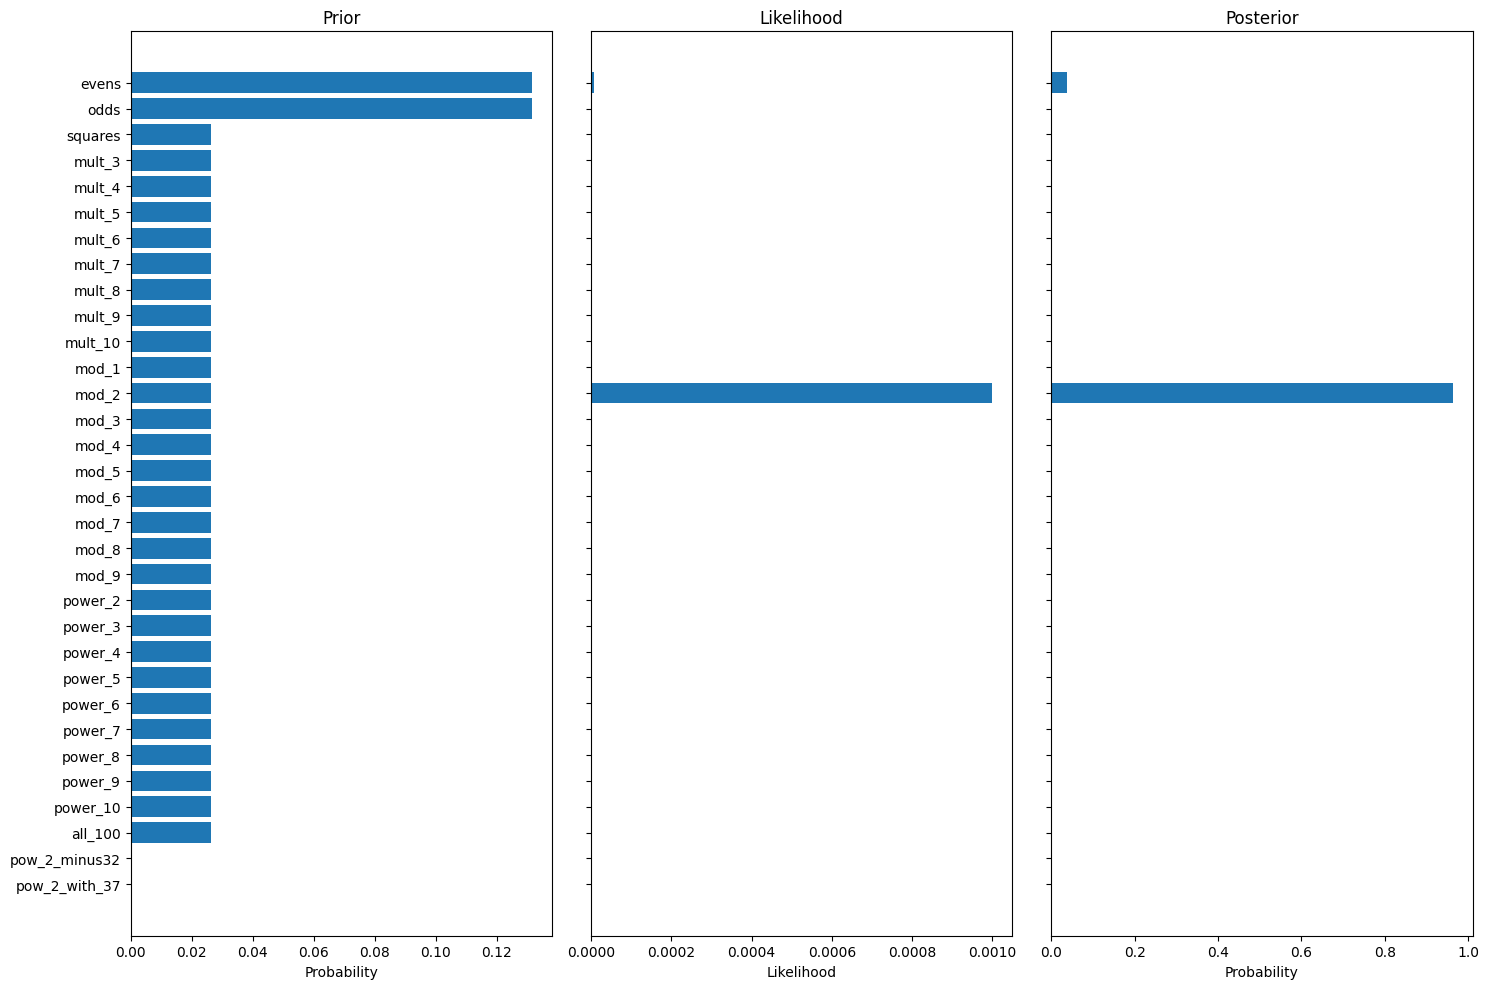

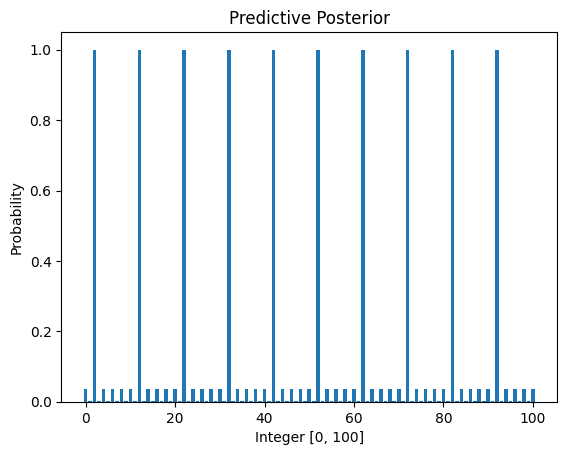

In [31]:
# Generate plots!
names = list(concepts.keys())
y = np.arange(len(names))

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 10),
    sharey=True
)

axes[0].barh(y, prior)
axes[0].set_title('Prior')
axes[0].set_xlabel('Probability')

axes[1].barh(y, likelihood)
axes[1].set_title('Likelihood')
axes[1].set_xlabel('Likelihood')

axes[2].barh(y, posterior)
axes[2].set_title('Posterior')
axes[2].set_xlabel('Probability')

axes[0].set_yticks(y)
axes[0].set_yticklabels(names)
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

# Plot posteriors.
x_vals = np.linspace(0, 100, 101, endpoint=True)
posterior_predictive = []
for x in x_vals:
    prob = 0
    for i, concept in enumerate(concepts.values()):
        if x in concept:
            prob += posterior[i]

    posterior_predictive.append(prob)

plt.bar(x_vals, posterior_predictive)
plt.xlabel('Integer [0, 100]')
plt.ylabel('Probability')
plt.title('Predictive Posterior')
plt.show()